<a href="https://colab.research.google.com/github/sohampalav/MyWebPage/blob/main/CSL701_CE34_ML_lab_exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Soham palav CE-34

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


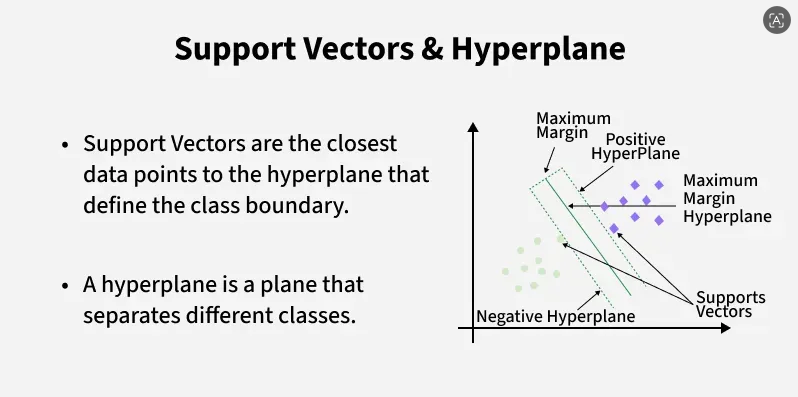
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print(df.head())

Saving Iris[1].csv to Iris[1].csv
Dataset loaded successfully!
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Task 2: Explore the Dataset

In [4]:
print("First 5 records:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['Species'].value_counts())

First 5 records:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:
               Id 

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [5]:
# Remove Id column
df = df.drop('Id', axis=1)

# Select input features
X = df[['SepalLengthCm',
        'SepalWidthCm',
        'PetalLengthCm',
        'PetalWidthCm']]

# Select target
y = df['Species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

Feature shape: (150, 4)
Target shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [6]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nData scaled successfully!")

Training data shape: (120, 4)
Testing data shape: (30, 4)

Data scaled successfully!


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [8]:
# Create Linear SVM model
svm_model = SVC(kernel='linear')

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred_svm)

print("Number of support vectors for each class:")
print(svm_model.n_support_)

print("\nTotal support vectors:")
print(len(svm_model.support_))

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
Number of support vectors for each class:
[ 2 11 10]

Total support vectors:
23


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Accuracy: 1.0
SVM Accuracy (%): 100.0
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


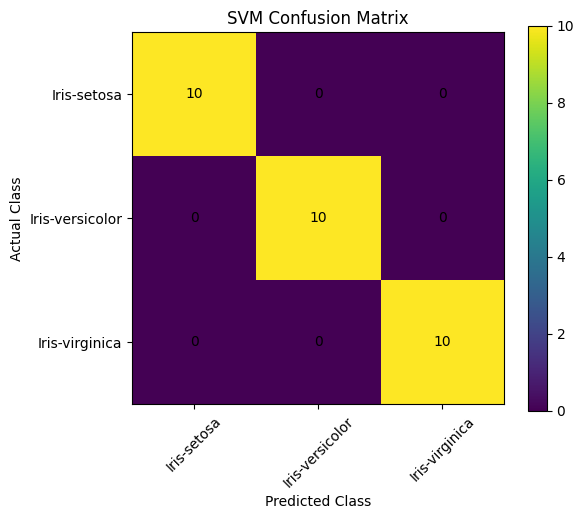

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [9]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)
print("SVM Accuracy (%):", accuracy_svm * 100)

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

plt.figure(figsize=(6, 5))

plt.imshow(cm_svm)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(svm_model.classes_)),
    svm_model.classes_,
    rotation=45
)

plt.yticks(
    range(len(svm_model.classes_)),
    svm_model.classes_
)

for i in range(len(cm_svm)):
    for j in range(len(cm_svm)):
        plt.text(j, i, cm_svm[i, j],
                 ha='center',
                 va='center')

plt.colorbar()
plt.show()

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

   PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2
2-D SVM Accuracy: 0.9333333333333333


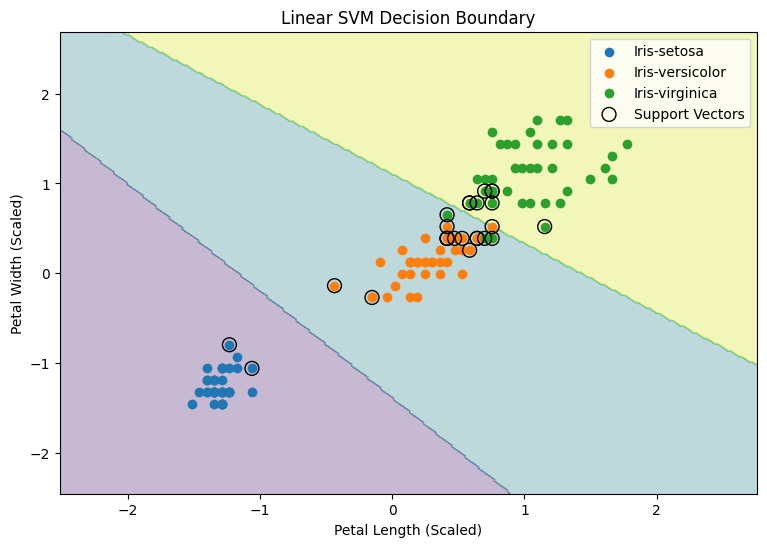

In [10]:
X_2d = df[['PetalLengthCm', 'PetalWidthCm']]
y_2d = df['Species']

print(X_2d.head())

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.20,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

svm_2d = SVC(kernel='linear')

svm_2d.fit(X2_train_scaled, y2_train)

y2_pred = svm_2d.predict(X2_test_scaled)

print("2-D SVM Accuracy:",
      accuracy_score(y2_test, y2_pred))

# Create mesh grid
x_min = X2_train_scaled[:, 0].min() - 1
x_max = X2_train_scaled[:, 0].max() + 1

y_min = X2_train_scaled[:, 1].min() - 1
y_max = X2_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for every point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = svm_2d.predict(grid_points)

Z = Z.reshape(xx.shape)

# Convert class names to numbers
class_numbers = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

y_numeric = y2_train.map(class_numbers)

# Plot decision regions
plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    np.vectorize(class_numbers.get)(
        Z
    ),
    alpha=0.3
)

# Plot training points
for class_name in svm_2d.classes_:
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        label=class_name
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    label='Support Vectors'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Accuracy: 0.9333333333333333
Logistic Regression Accuracy (%): 93.33333333333333


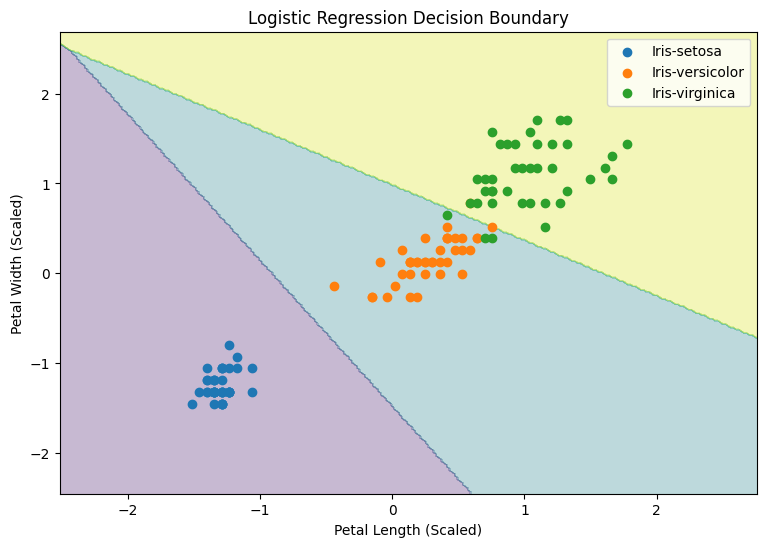

In [11]:
# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

# Train model
logistic_model.fit(X2_train_scaled, y2_train)

# Make predictions
y2_pred_logistic = logistic_model.predict(X2_test_scaled)

# Calculate accuracy
accuracy_logistic = accuracy_score(
    y2_test,
    y2_pred_logistic
)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

print("Logistic Regression Accuracy (%):",
      accuracy_logistic * 100)

# Predict grid points
Z_logistic = logistic_model.predict(grid_points)

Z_logistic = Z_logistic.reshape(xx.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    np.vectorize(class_numbers.get)(Z_logistic),
    alpha=0.3
)

# Plot training points
for class_name in logistic_model.classes_:
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        label=class_name
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()



# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

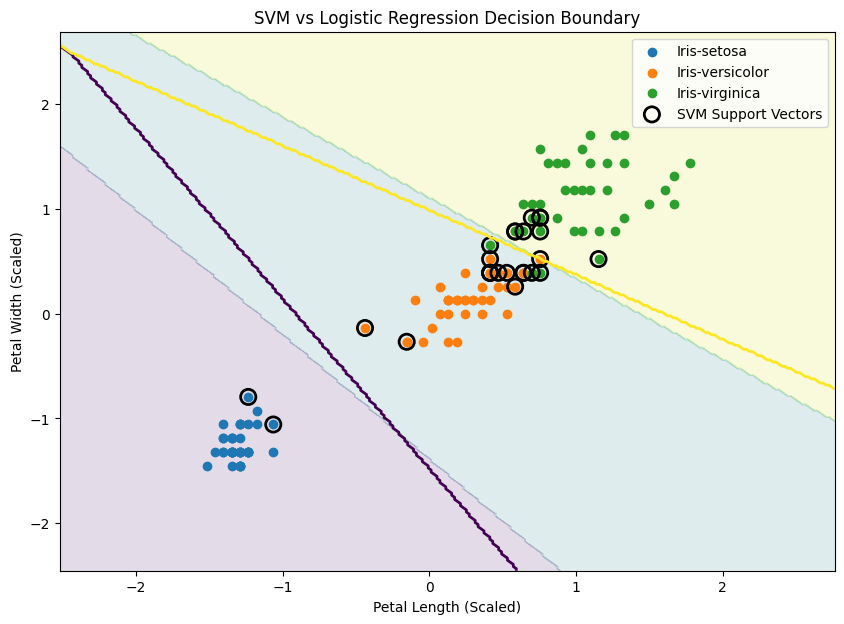

In [12]:
plt.figure(figsize=(10, 7))

# SVM decision regions
plt.contourf(
    xx,
    yy,
    np.vectorize(class_numbers.get)(Z),
    alpha=0.15
)

# Logistic Regression decision regions
plt.contour(
    xx,
    yy,
    np.vectorize(class_numbers.get)(Z_logistic),
    levels=[0.5, 1.5],
    linewidths=2
)

# Plot data points
for class_name in svm_2d.classes_:
    indices = y2_train == class_name

    plt.scatter(
        X2_train_scaled[indices, 0],
        X2_train_scaled[indices, 1],
        label=class_name
    )

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=120,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='SVM Support Vectors'
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [14]:
print("Performance Comparison")
print("=" * 40)

print("Linear SVM Accuracy:",
      accuracy_score(y2_test, y2_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y2_test, y2_pred_logistic))
cm_svm_2d = confusion_matrix(
    y2_test,
    y2_pred
)

print("SVM Confusion Matrix:")
print(cm_svm_2d)

cm_logistic = confusion_matrix(
    y2_test,
    y2_pred_logistic
)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

print("SVM Classification Report:")
print(
    classification_report(
        y2_test,
        y2_pred
    )
)
print("Logistic Regression Classification Report:")
print(
    classification_report(
        y2_test,
        y2_pred_logistic
    )
)
comparison = pd.DataFrame({
    'Model': [
        'Linear SVM',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_score(y2_test, y2_pred),
        accuracy_score(y2_test, y2_pred_logistic)
    ]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

print(comparison)

Performance Comparison
Linear SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333
SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93      

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.